In [1]:
%pip install more-itertools transforms3d torch-ema wandb pyinstrument

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.9/144.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [2]:
import torch
import wandb
from torch import nn
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler
from torch.amp import autocast
from torchvision.transforms import v2
from transforms3d.axangles import axangle2mat
from transforms3d.euler import quat2euler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from torchtune.training import get_cosine_schedule_with_warmup
from torch_ema import ExponentialMovingAverage
import packaging
import torch.cuda.nccl as nccl
import torch.distributed as dist
from scipy import signal
import more_itertools
from typing import Optional, Tuple
from datetime import datetime
from zoneinfo import ZoneInfo
from pyinstrument import Profiler
import logging
import pandas as pd
import numpy as np
import warnings
import cProfile
import pstats
import random
import math
import time
import io
import os
warnings.filterwarnings('ignore')

In [3]:
profile_code = False

In [4]:
wandb.login(key="efd7fe9ee6eb7c3b65bceb9b5e86416b97b8dee4") # TODO - remove key after completion

wandb_settings = wandb.Settings(
    show_errors=True,
    silent=True,
    show_warnings=True
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aneelam (aneelam-cal-state-university-northridge) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    data_path = "/kaggle/input/duo-gait" # path for kaggle environment
elif os.getenv("COLAB_RELEASE_TAG"):
    from google.colab import drive
    drive.mount('drive')
    data_path = "drive/MyDrive/Colab Notebooks/Datasets" # path for google colab environment
else:
    data_path = "../../data" # path for local environment

In [6]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

**Seed for consistent results**

In [7]:
seed = 42
gen = torch.Generator()
gen.manual_seed(seed)

random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)

**Enable CUDA if available**

In [8]:
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_type)

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = False
    torch.cuda.manual_seed(42)
    torch.set_float32_matmul_precision("high")

use_bf16 = (
    torch.version.cuda
    and torch.cuda.is_bf16_supported()
    and packaging.version.parse(torch.version.cuda).release >= (11, 0)
    and dist.is_nccl_available()
    and nccl.version() >= (2, 10)
) # from https://www.youtube.com/watch?v=-caN92JtKqA
amp_dtype = torch.bfloat16 if use_bf16 else torch.float16
use_bf16

Tesla T4
CUDA Version: 12.4


True

**Custom Transforms**

In [9]:
class ConditionalTransform:
    def __init__(self, transform, enabled=True):
        self.transform = transform
        self.enabled = enabled

    def __call__(self, x):
        if self.enabled:
            return self.transform(x)
        return x

In [10]:
class RandomJitter(object):
    def __init__(self, sigma=0.03):
        self.sigma = sigma

    # https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def DA_Jitter(self, X):
        myNoise = np.random.normal(loc=0, scale=self.sigma, size=X.shape)
        return X + myNoise

    def __call__(self, input):
        output = self.DA_Jitter(input.transpose())
        return output.transpose()

In [11]:
class RandomScaling(object):
    def __init__(self, sigma=0.1):
        self.sigma = sigma

    # modified from https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def __call__(self, input):
        scalingFactor = np.random.normal(loc=1.0, scale=self.sigma, size=(input.shape[0], 1)).astype(input.dtype, copy=False)
        myNoise = np.matmul(scalingFactor, np.ones((1, input.shape[1]), dtype=input.dtype))
        return input * myNoise

In [12]:
class RandomRotation(object):
    def __init__(self, degree=10):
        self.rad = np.deg2rad(degree)

    # https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def DA_Rotation(self, X):
        angle = np.random.uniform(low=-self.rad, high=self.rad)
        axis = np.random.uniform(low=-1, high=1, size=3)
        return np.matmul(X, axangle2mat(axis, angle))

    def __call__(self, input): # TODO - consider applying rotation per sensor instead of every 3 channels
        input = input.transpose()
        output = np.zeros_like(input)
        channels = input.shape[1]
        for i in range(channels//3):
            output[:,i*3:i*3+3] = self.DA_Rotation(input[:,i*3:i*3+3])
        return output.transpose()

In [13]:
class RandomPermutation(object):
    def __init__(self, nperm=4, minseglength=100):
        self.nperm = nperm
        self.minseglength = minseglength

    # https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def DA_Permutation(self, X, nPerm, minSegLength):
        X_new = np.zeros(X.shape)
        idx = np.random.permutation(nPerm)
        bWhile = True
        while bWhile == True:
            segs = np.zeros(nPerm+1, dtype=int)
            segs[1:-1] = np.sort(np.random.randint(minSegLength, X.shape[0]-minSegLength, nPerm-1))
            segs[-1] = X.shape[0]
            if np.min(segs[1:]-segs[0:-1]) > minSegLength:
                bWhile = False
        pp = 0
        for ii in range(nPerm):
            x_temp = X[segs[idx[ii]]:segs[idx[ii]+1],:]
            X_new[pp:pp+len(x_temp),:] = x_temp
            pp += len(x_temp)
        return(X_new)

    def __call__(self, input):
        input = input.transpose()
        output = np.zeros_like(input)
        channels = input.shape[1]
        for i in range(channels//3):
            output[:,i*3:i*3+3] = self.DA_Permutation(input[:,i*3:i*3+3], self.nperm, self.minseglength)
        return output.transpose()

In [14]:
class RandomMagWarp(object):
    def __init__(self, sigma=0.1, knot=4):
        self.sigma = sigma
        self.knot = knot

    # https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def GenerateRandomCurves(self, X, sigma, knot):
        xx = (np.ones((X.shape[1],1))*(np.arange(0,X.shape[0], (X.shape[0]-1)/(knot+1)))).transpose()
        yy = np.random.normal(loc=1.0, scale=sigma, size=(knot+2, X.shape[1]))
        x_range = np.arange(X.shape[0])
        cs_x = CubicSpline(xx[:,0], yy[:,0])
        cs_y = CubicSpline(xx[:,1], yy[:,1])
        cs_z = CubicSpline(xx[:,2], yy[:,2])
        return np.array([cs_x(x_range),cs_y(x_range),cs_z(x_range)]).transpose()
    
    def DA_MagWarp(self, X, sigma):
        return X * self.GenerateRandomCurves(X, sigma)

    def __call__(self, input):
        input = input.transpose()
        output = np.zeros_like(input)
        channels = input.shape[1]
        for i in range(channels//3):
            output[:,i*3:i*3+3] = self.DA_MagWarp(input[:,i*3:i*3+3], self.sigma, self.knot)
        return output.transpose()

In [15]:
class RandomTimeWarp(object):
    def __init__(self, sigma=0.1, knot=4):
        self.sigma = sigma
        self.knot = knot
    
    # https://github.com/terryum/Data-Augmentation-For-Wearable-Sensor-Data/blob/master/Example_DataAugmentation_TimeseriesData.ipynb
    def GenerateRandomCurves(self, X, sigma, knot):
        xx = (np.ones((X.shape[1],1))*(np.arange(0,X.shape[0], (X.shape[0]-1)/(knot+1)))).transpose()
        yy = np.random.normal(loc=1.0, scale=sigma, size=(knot+2, X.shape[1]))
        x_range = np.arange(X.shape[0])
        cs_x = CubicSpline(xx[:,0], yy[:,0])
        cs_y = CubicSpline(xx[:,1], yy[:,1])
        cs_z = CubicSpline(xx[:,2], yy[:,2])
        return np.array([cs_x(x_range),cs_y(x_range),cs_z(x_range)]).transpose()

    def DistortTimesteps(self, X, sigma, knot):
        tt = self.GenerateRandomCurves(X, sigma, knot) # Regard these samples around 1 as time intervals
        tt_cum = np.cumsum(tt, axis=0)        # Add intervals to make a cumulative graph
        # Make the last value to have X.shape[0]
        t_scale = [(X.shape[0]-1)/tt_cum[-1,0],(X.shape[0]-1)/tt_cum[-1,1],(X.shape[0]-1)/tt_cum[-1,2]]
        tt_cum[:,0] = tt_cum[:,0]*t_scale[0]
        tt_cum[:,1] = tt_cum[:,1]*t_scale[1]
        tt_cum[:,2] = tt_cum[:,2]*t_scale[2]
        return tt_cum

    def DA_TimeWarp(self, X, sigma, knot):
        tt_new = self.DistortTimesteps(X, sigma, knot)
        X_new = np.zeros(X.shape)
        x_range = np.arange(X.shape[0])
        X_new[:,0] = np.interp(x_range, tt_new[:,0], X[:,0])
        X_new[:,1] = np.interp(x_range, tt_new[:,1], X[:,1])
        X_new[:,2] = np.interp(x_range, tt_new[:,2], X[:,2])
        return X_new

    def __call__(self, input):
        input = input.transpose()
        output = np.zeros_like(input)
        channels = input.shape[1]
        for i in range(channels//3):
            output[:,i*3:i*3+3] = self.DA_TimeWarp(input[:,i*3:i*3+3], self.sigma, self.knot)
        return output.transpose()

In [16]:
class ButterworthFilter(object):
    def __init__(self, cutoff, order, fs):
        nyquist = 0.5 * fs
        normal_cutoff = cutoff / nyquist
        self.b, self.a = signal.butter(order, normal_cutoff, btype='low', analog=False)

    def __call__(self, input):
        output = signal.filtfilt(self.b, self.a, input).astype(np.float32)
        return output

In [17]:
class PadTrimToLength(object):
    def __init__(self, padlen):
        self.padlen = padlen

    def __call__(self, input):
        input = torch.from_numpy(input.copy()) # convert to tensor
        padded = F.pad(input, (0, max(0, self.padlen - input.shape[1])))
        output = torch.narrow(padded, 1, 0, self.padlen) # surely this works with smaller dimension 1 than padlen
        return output

In [18]:
class Normalize(object):
    def __init__(self, mean, std, epsilon=1e-7):
        self.mean = mean
        self.std = std
        self.epsilon = epsilon

    def __call__(self, input):
        output = (input - self.mean) / (self.std + self.epsilon)
        return output

**Define dataset pipeline**

In [19]:
class DUO_GAIT(Dataset):
    def __init__(self, freq, allowed_sensors, num_participants, ignore_participant_ids, remove_imu_xyz=False, compute_jerk=True, include_norm=True, include_angle=True, include_dt=True, remove_outliers=True, pre_transform=None, transform=None, target_transform=None):
        self.num_participants = num_participants
        self.allowed_sensors = allowed_sensors
        self.imu_signals = []
        self.freq = freq
        
        self.pre_transform = pre_transform

        foot_strides_df = None
        sensor_dict = {}
        for participant_id in range(1, num_participants+1):
            if participant_id in ignore_participant_ids:
                continue

            for sensor_location in self.allowed_sensors:
                for protocol in ["control", "fatigue"]:
                    for task in ["st", "dt"]:
                        if task == "dt" and not include_dt: # skip dual task if we don't want it
                            continue

                        interim_file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{participant_id:02}/{sensor_location}.csv"
                        interim_sensor_df = pd.read_csv(interim_file_name)
                        interim_sensor_df.rename({ "timestamp": "Time (secs)", "Unnamed: 0": "Sample" }, axis=1, inplace=True)

                        if include_angle:
                            raw_file_name = f"{data_path}/DUO-GAIT/raw/OG_{task}_raw/sub_{participant_id:02}/{sensor_location}.csv"
                            raw_sensor_df = pd.read_csv(raw_file_name,skiprows=5).drop(index=0).astype(float)
                            raw_sensor_df = raw_sensor_df.filter(["Quat W", "Quat X", "Quat Y", "Quat Z"], axis=1)
                            raw_sensor_df.rename({ "Quat W": "QuatW", "Quat X": "QuatX", "Quat Y": "QuatY", "Quat Z": "QuatZ" },axis=1, inplace=True, errors='raise')
                            
                            quat_features_df = raw_sensor_df.loc[interim_sensor_df['Sample'].min(): interim_sensor_df['Sample'].max()].reset_index(drop=True)
                            euler_angles = quat_features_df.apply(lambda row: quat2euler(row, axes='sxyz'), axis=1)
                            euler_features_df = pd.DataFrame(euler_angles.tolist(), index=euler_angles.index, columns=['EulerX', 'EulerY', 'EulerZ']).reset_index(drop=True) # get euler angles

                            interim_sensor_df = pd.merge(interim_sensor_df, euler_features_df, left_index=True, right_index=True, how='inner')

                        sensor_dict[interim_file_name] = interim_sensor_df
            # save interim files for future

            for protocol in ["control", "fatigue"]:
                for foot in ["left", "right"]:
                    for task in ["st", "dt"]:
                        if task == "dt" and not include_dt: # skip dual task if we don't want it
                            continue

                        foot_df = pd.read_csv(f"{data_path}/DUO-GAIT/processed/OG_{task}_{protocol}/sub_{participant_id:02}/{foot}_foot_core_params.csv")
                        foot_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
                        foot_df['is_fatigue'] = int(protocol == "fatigue")
                        foot_df['is_dual_task'] = int(task == "dt")
                        foot_df['Participant'] = participant_id

                        is_control = (protocol == "control")
                        is_dual_task = (task == "dt")
                        
                        self.create_start_end_samples_strides(sensor_dict, foot_df, participant_id, is_control=is_control, is_dual_task=is_dual_task)
                        foot_strides_df = pd.concat([foot_strides_df, foot_df], axis=0)

        if remove_outliers:
            foot_strides_df = foot_strides_df[foot_strides_df['is_outlier']==False].reset_index(drop=True)

        for _, row in foot_strides_df.iterrows():
            imu_signals_df_list = []
            for sensor_location in self.allowed_sensors:
                protocol = "fatigue" if row['is_fatigue'] else "control"
                task = "dt" if row['is_dual_task'] else "st"
                file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{row['Participant']:02}/{sensor_location}.csv"

                sensor_df = sensor_dict[file_name]
                sensor_df = sensor_df[(sensor_df['Sample'] >= row['start_samples']) & (sensor_df['Sample'] <= row['end_samples'])]

                acc_columns = ["AccX", "AccY", "AccZ"]
                gyr_columns = ["GyrX", "GyrY", "GyrZ"]
                angle_columns = ["EulerX", "EulerY", "EulerZ"] if include_angle else []

                acc_cols_pref = [f"{sensor_location}_{c}" for c in acc_columns]
                gyr_cols_pref = [f"{sensor_location}_{c}" for c in gyr_columns]

                sensor_signals_df = sensor_df[acc_columns + gyr_columns + angle_columns].reset_index(drop=True)
                sensor_signals_df = sensor_signals_df.add_prefix(f"{sensor_location}_")

                if compute_jerk:
                    acc_gyro_df = sensor_df[acc_columns + gyr_columns]
                    acc_gyro_np = acc_gyro_df.to_numpy().transpose().astype(np.float32)
                    jerk_np = np.gradient(acc_gyro_np, 1.0 / self.freq, axis=1).transpose()
                    jerk_df = pd.DataFrame(data=jerk_np, columns=["Jerk" + col for col in (acc_columns + gyr_columns)])
                    jerk_df = jerk_df.add_prefix(f"{sensor_location}_")
                    sensor_signals_df = pd.concat([sensor_signals_df, jerk_df], axis=1)

                if include_norm:
                    sensor_signals_df[f"{sensor_location}_AccM"] = np.linalg.norm(
                        sensor_signals_df[acc_cols_pref].to_numpy(), axis=1
                    )
                    sensor_signals_df[f"{sensor_location}_GyrM"] = np.linalg.norm(
                        sensor_signals_df[gyr_cols_pref].to_numpy(), axis=1
                    )

                if remove_imu_xyz:
                    sensor_signals_df.drop(columns=acc_cols_pref + gyr_cols_pref, inplace=True)

                imu_signals_df_list.append(sensor_signals_df)

            imu_signals_df = pd.concat(imu_signals_df_list, axis=1)
            imu_signals_np = imu_signals_df.to_numpy().transpose().astype(np.float32)
            
            if self.pre_transform:
                imu_signals_np = self.pre_transform(imu_signals_np)

            self.imu_signals.append(imu_signals_np)
        
        self.participant = foot_strides_df['Participant'].to_numpy()
        self.is_fatigue = foot_strides_df['is_fatigue'].to_numpy()
        self.num_channels = self.imu_signals[0].shape[0]
        
        self.kept_participants_size = np.unique(self.participant).shape[0]
        self.transform = transform
        self.target_transform = target_transform

    def create_start_end_samples_strides(self, sensor_dict, df, participant_id, is_control, is_dual_task):
        df.sort_values(by='stride_index', inplace=True)
        df['start_samples'] = df['ic_samples'].shift(1)
        target_time = df.loc[0, 'start_times']
        
        protocol = "control" if is_control else "fatigue"
        task = "dt" if is_dual_task else "st"

        file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{participant_id:02}/{self.allowed_sensors[0]}.csv"        
        fatigue_df = sensor_dict[file_name].copy() # copy to avoid changing sensor dict's dataframes
        fatigue_df['Delta (secs)'] = fatigue_df['Time (secs)'] - fatigue_df['Time (secs)'].min() # delta time

        ts_eq_check = fatigue_df['Delta (secs)'].apply(lambda x: math.isclose(x, target_time, rel_tol=1e-5))
        start_sample = fatigue_df[ts_eq_check]['Sample'].item() - fatigue_df['Sample'].min()

        df.loc[0, 'start_samples'] = start_sample
        df['start_samples'] = df['start_samples'] + fatigue_df['Sample'].min()
        df['end_samples'] = df['ic_samples'] + fatigue_df['Sample'].min() - 1 # make it inclusive for ending samples too

        df['start_samples'] = df['start_samples'].astype(np.int64)
        df['end_samples'] = df['end_samples'].astype(np.int64)

    def __len__(self):
        return len(self.is_fatigue)

    def __getitem__(self, idx):
        imu_signals_np = self.imu_signals[idx]
        label = self.is_fatigue[idx].item()
        participant = self.participant[idx].item()

        if self.transform:
            imu_signals_np = self.transform(imu_signals_np)

        if self.target_transform:
            label = self.target_transform(label)

        return imu_signals_np, participant, label

**DeepConvLSTMSelfAttention Architecture**

In [20]:
# https://github.com/sooftware/attentions/blob/master/attentions.py
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot-Product Attention proposed in "Attention Is All You Need"
    Compute the dot products of the query with all keys, divide each by sqrt(dim),
    and apply a softmax function to obtain the weights on the values

    Args: dim, mask
        dim (int): dimention of attention
        mask (torch.Tensor): tensor containing indices to be masked

    Inputs: query, key, value, mask
        - **query** (batch, q_len, d_model): tensor containing projection vector for decoder.
        - **key** (batch, k_len, d_model): tensor containing projection vector for encoder.
        - **value** (batch, v_len, d_model): tensor containing features of the encoded input sequence.
        - **mask** (-): tensor containing indices to be masked

    Returns: context, attn
        - **context**: tensor containing the context vector from attention mechanism.
        - **attn**: tensor containing the attention (alignment) from the encoder outputs.
    """
    def __init__(self, dim: int):
        super(ScaledDotProductAttention, self).__init__()
        self.sqrt_dim = np.sqrt(dim)

    def forward(self, query: Tensor, key: Tensor, value: Tensor, mask: Optional[Tensor] = None) -> Tuple[Tensor, Tensor]:
        score = torch.bmm(query, key.transpose(1, 2)) / self.sqrt_dim

        if mask is not None:
            score.masked_fill_(mask.view(score.size()), -float('Inf'))

        attn = F.softmax(score, -1)
        context = torch.bmm(attn, value)
        return context, attn

In [21]:
class ProjectionMLP(nn.Module):
	def __init__(self, in_size, p_drop=0.5, hidden=[128, 128]):
		super().__init__()
		self.name = 'MLP'
		self.linear1 = nn.Sequential(
			nn.Linear(in_size, hidden[0], bias=False),
			nn.BatchNorm1d(hidden[0]),
			nn.ReLU(inplace=True),
   			nn.Dropout(p_drop)
		)
		self.linear2 = nn.Sequential(
			nn.Linear(hidden[0], hidden[1])
		)

	def forward(self, x):
		x = self.linear1(x)
		x = self.linear2(x)
		return x

In [22]:
class FatigueCNN(nn.Module):
    def __init__(self, in_channels, p_drop):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=5, stride=1, padding=0),
            nn.ReLU()
        )
        self.gap = nn.AdaptiveMaxPool1d(1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=p_drop)
        self.linear = nn.Linear(32, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear(x)
        return x

**Good Parameters**

In [23]:
enable_wandb = True
use_amp = True

model_class = FatigueCNN

**Dataset Parameters**

In [24]:
compute_jerk = True
remove_imu_xyz = True
include_norm = True
include_angle = False
include_dt = False

**Experiment Parameters**

In [25]:
num_participants = 18
ignore_participant_ids = [4, 16]

allowed_sensors = ["SA"]
num_samples = 160
freq = 128

**Hyper Parameters**

In [26]:
epochs_sup = 300
batch_size_sup = 128
learning_rate_sup = 0.0001
train_percent = 0.70
val_percent = 0.15
p_drop = 0.50
label_smooth = 0.1
weight_decay = 0.01
ema_decay = 0.999

freezenet = False

**Transform Parameters**

In [27]:
enable_butterworth_filter = True
enable_random_jitter = False
enable_random_scaling = True
enable_random_rotation = False
enable_random_timewarp = False
enable_random_magwarp = False

transform_dict = {
    'filter_butterw': enable_butterworth_filter,
    'random_jitter': enable_random_jitter,
    'random_scale': enable_random_scaling,
    'random_rot': enable_random_rotation,
    'random_timewarp': enable_random_timewarp,
    'random_magwarp': enable_random_magwarp,
}

enabled_transforms = []
for key, is_enabled in transform_dict.items():
    if is_enabled:
        enabled_transforms.append(key)

**Wandb Config**

In [28]:
wandb_config = {
    "architecture": model_class.__name__,
    "training_setup": {
        "batch_size": batch_size_sup,
        "learning_rate": learning_rate_sup,
        "epochs": epochs_sup,
        "dropout": p_drop,
        "weight_decay": weight_decay,
        "ema_decay": ema_decay,
        "label_smooth": label_smooth,
        "train_percent": train_percent,
    },
    "data_features": {
        "compute_jerk": compute_jerk,
        "remove_imu_xyz": remove_imu_xyz,
        "include_norm": include_norm,
        "include_angle": include_angle,
        "include_dt": include_dt,
        "allowed_sensors" : allowed_sensors
    },
    "augmentation": {
        "enable_butterworth_filter": enable_butterworth_filter,
        "enable_random_jitter": enable_random_jitter,
        "enable_random_scaling": enable_random_scaling,
        "enable_random_rotation": enable_random_rotation,
        "enable_random_timewarp": enable_random_timewarp,
        "enable_random_magwarp": enable_random_magwarp
    }
}

**Create dataset**

In [29]:
pre_transform = ConditionalTransform(ButterworthFilter(cutoff=10.0, order=3, fs=128.0), enabled=enable_butterworth_filter) # precompute butterworth for all windows

In [30]:
print("Loading Dataset ...")
dataset = DUO_GAIT(freq, allowed_sensors, num_participants, ignore_participant_ids, remove_imu_xyz, compute_jerk, include_norm, include_angle, include_dt, pre_transform=pre_transform)
print("Dataset Loaded ...")

Loading Dataset ...
Dataset Loaded ...


**Begin profiler**

In [31]:
profiler = Profiler()
if profile_code:
    profiler.start()

**Leave one Participant out Training Loop**

In [32]:
pacific_tz = ZoneInfo("America/Los_Angeles")
now_pst = datetime.now(pacific_tz)
timestamp = now_pst.strftime("%b-%d-%Y %I-%M-%S %p")
arch_name = model_class.__name__

dataset_size = len(dataset)

train_size = int(train_percent * len(dataset))
val_size = int(val_percent * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, valid_set, test_set = random_split(dataset, [train_size, val_size, test_size], generator=gen)

dataset.transform = v2.Compose([
    PadTrimToLength(padlen=num_samples),
])

stat_loader = DataLoader(train_set, batch_size=batch_size_sup, generator=gen)

full_train_data = []
for batch_idx, (pre_train_features, pre_train_participants, pre_train_labels) in enumerate(stat_loader):
    full_train_data.append(pre_train_features)

full_train_data = torch.concat(full_train_data, dim=0)
std, mean = torch.std_mean(full_train_data, dim=(0, 2), keepdim=True)
# compute mean and std over all channels separately

std = torch.squeeze(std, dim=0)
mean = torch.squeeze(mean, dim=0)
# remove the batch dimension

augmented_supervised_transform = v2.Compose([
    ConditionalTransform(RandomJitter(sigma=0.01),enabled=enable_random_jitter),
    ConditionalTransform(RandomScaling(sigma=0.2),enabled=enable_random_scaling),
    ConditionalTransform(RandomRotation(degree=10),enabled=enable_random_rotation),
    ConditionalTransform(RandomTimeWarp(sigma=0.2, knot=4),enabled=enable_random_timewarp),
    ConditionalTransform(RandomMagWarp(sigma=0.2, knot=4),enabled=enable_random_magwarp),
    PadTrimToLength(padlen=num_samples),
    Normalize(mean=mean, std=std),
])

norm_transform = v2.Compose([
    PadTrimToLength(padlen=num_samples),
    Normalize(mean=mean, std=std),
])

model = model_class(dataset.num_channels, p_drop).to(device=device)
# move model to device

wandb_run = wandb.init(
    mode="online" if enable_wandb else "disabled",
    project="fatigue-detection",
    group=f"{arch_name} {timestamp}",
    config=wandb_config,
    reinit="create_new",
    settings=wandb_settings
)

# supervised metrics
wandb_run.define_metric(name='sup/lr',step_metric='epoch')
wandb_run.define_metric(name='sup/train_loss',step_metric='epoch')
wandb_run.define_metric(name='sup/train_accuracy',step_metric='epoch')
wandb_run.define_metric(name='sup/train_time_secs',step_metric='epoch')
wandb_run.define_metric(name='sup/valid_loss',step_metric='epoch')
wandb_run.define_metric(name='sup/valid_accuracy',step_metric='epoch')
wandb_run.define_metric(name='sup/valid_time_secs',step_metric='epoch')

ce_loss = nn.CrossEntropyLoss(label_smoothing=label_smooth)
tracked_parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(tracked_parameters, lr=learning_rate_sup, weight_decay=weight_decay, fused=True)
ema = ExponentialMovingAverage(tracked_parameters, decay=ema_decay)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=10, num_training_steps=epochs_sup)
sup_scaler = GradScaler(enabled=use_amp and not use_bf16)

print(f"Beginning training with normal split")
for epoch in range(0, epochs_sup):
    train_epoch_loss = torch.zeros((), device=device)
    valid_epoch_loss = torch.zeros((), device=device)

    train_epoch_preds, train_epoch_labels = [], []
    valid_epoch_preds, valid_epoch_labels = [], []

    dataset.transform = augmented_supervised_transform

    train_loader = DataLoader(train_set, batch_size=batch_size_sup, shuffle=True, pin_memory=True, drop_last=False, generator=gen)
    # create dataloader for training

    train_start_time = time.time()
    model.train()
    for batch_idx, (train_features, _, train_labels) in enumerate(train_loader):
        train_features = train_features.to(device, non_blocking=True)
        train_labels = train_labels.to(device, non_blocking=True) # move data to device
        train_batch_size = train_labels.size(0)

        optimizer.zero_grad()

        with autocast(dtype=amp_dtype, device_type=device_type, enabled=use_amp):
            logits = model(train_features)
            train_batch_loss = ce_loss(logits, train_labels)
            
        predictions = torch.argmax(logits, dim=1)
        train_epoch_preds.append(predictions)
        train_epoch_labels.append(train_labels)

        sup_scaler.scale(train_batch_loss).backward()
        sup_scaler.step(optimizer)
        sup_scaler.update()
        ema.update()

        train_epoch_loss += train_batch_loss.detach() * train_batch_size
    train_end_time = time.time()

    dataset.transform = norm_transform

    valid_loader = DataLoader(valid_set, batch_size=batch_size_sup, shuffle=False, pin_memory=True, drop_last=False, generator=gen)
    # create dataloader for validation

    model.eval()
    valid_start_time = time.time()
    with ema.average_parameters():
        with torch.inference_mode():
            for batch_idx, (valid_features, _, valid_labels) in enumerate(valid_loader):
                valid_features = valid_features.to(device, non_blocking=True)
                valid_labels = valid_labels.to(device, non_blocking=True) # move to device
                valid_batch_size = valid_labels.size(0)
                
                with autocast(dtype=amp_dtype, device_type=device_type, enabled=use_amp):
                    logits = model(valid_features)
                    valid_batch_loss = ce_loss(logits, valid_labels)

                predictions = torch.argmax(logits, dim=1)
                valid_epoch_preds.append(predictions)
                valid_epoch_labels.append(valid_labels)

                valid_epoch_loss += valid_batch_loss.detach() * valid_batch_size
    valid_end_time = time.time()
    
    train_epoch_loss = train_epoch_loss.item()
    valid_epoch_loss = valid_epoch_loss.item()
    train_epoch_loss /= len(train_set)
    valid_epoch_loss /= len(valid_set)

    train_epoch_preds = torch.cat(train_epoch_preds).cpu().numpy()
    train_epoch_labels = torch.cat(train_epoch_labels).cpu().numpy()
    valid_epoch_preds = torch.cat(valid_epoch_preds).cpu().numpy()
    valid_epoch_labels = torch.cat(valid_epoch_labels).cpu().numpy()

    train_epoch_acc = accuracy_score(train_epoch_labels, train_epoch_preds)
    valid_epoch_acc = accuracy_score(valid_epoch_labels, valid_epoch_preds)

    scheduler.step() # step the scheduler
    
    wandb_run.log({
        'sup/lr': scheduler.get_last_lr()[0],

        'sup/train_loss': train_epoch_loss,
        'sup/train_accuracy': train_epoch_acc,
        'sup/train_time_secs': train_end_time - train_start_time,

        'sup/valid_loss': valid_epoch_loss,
        'sup/valid_accuracy': valid_epoch_acc,
        'sup/valid_time_secs': valid_end_time - valid_start_time,
        'epoch': epoch
    })

test_loader = DataLoader(test_set, batch_size=batch_size_sup, shuffle=False, pin_memory=True, generator=gen)
# create dataloader for testing

test_loss = torch.zeros((), device=device)
test_preds, test_labels = [], []

# testing
model.eval()
with ema.average_parameters():
    with torch.inference_mode():
        for batch_idx, (test_features, _, test_batch_labels) in enumerate(test_loader):
            test_features = test_features.to(device, non_blocking=True)
            test_batch_labels = test_batch_labels.to(device, non_blocking=True) # move to device
            test_batch_size = test_batch_labels.size(0)
            
            with autocast(dtype=amp_dtype, device_type=device_type, enabled=use_amp):
                logits = model(test_features)
                test_batch_loss = ce_loss(logits, test_batch_labels)

            predictions = torch.argmax(logits, dim=1)
            test_preds.append(predictions)
            test_labels.append(test_batch_labels)

            test_loss += test_batch_loss.detach() * test_batch_size

test_loss = test_loss.item()
test_loss /= len(test_set)

test_preds = torch.cat(test_preds).cpu().numpy()
test_labels = torch.cat(test_labels).cpu().numpy()

test_acc = accuracy_score(test_labels, test_preds)
test_f1_score = f1_score(test_labels, test_preds)

print("Test F1-score:", test_f1_score)
print("Test Acc:", test_acc)
print("Test Loss:", test_loss)

Beginning training with normal split
Test F1-score: 0.9315960912052118
Test Acc: 0.9346698928447977
Test Loss: 0.4012965529672917


**Confusion Matrix**

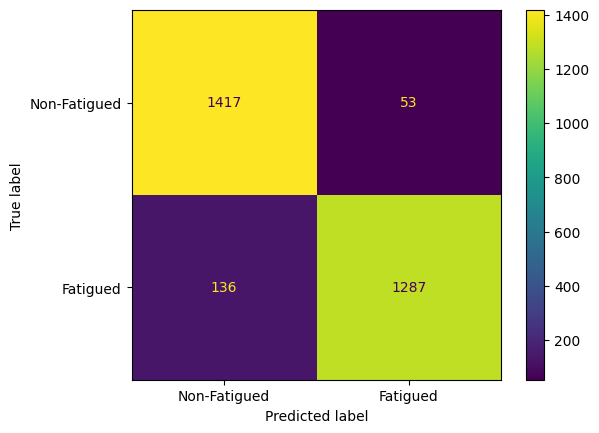

In [33]:
labels = ['Non-Fatigued', 'Fatigued']

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.show()

wandb_cm = wandb.plot.confusion_matrix(y_true=test_labels, preds=test_preds, class_names=labels, title="Confusion Matrix")
wandb_run.log({"fatigue_confusion_matrix": wandb_cm})

**Stop Profiler**

In [34]:
if profile_code:
    profiler.stop()
    profiler.open_in_browser()

In [35]:
wandb_run.finish()